In [243]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from scipy.optimize import fmin_cobyla
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import emcee
import corner.corner
from scipy.stats import gaussian_kde

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_7076\224906477.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


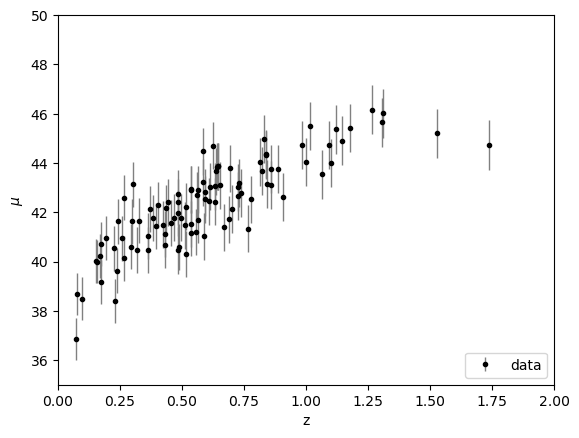

In [245]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [247]:
z_sample
mu_sample
dmu

array([0.91862497, 0.95818624, 0.94340343, 0.97222794, 0.97171179,
       0.92819662, 0.92860378, 0.97385018, 0.9966678 , 0.98218018,
       0.93649091, 0.948558  , 0.96318467, 0.9656542 , 0.93760835,
       0.95334492, 0.94872528, 0.86485225, 0.97103496, 0.98306194,
       0.93712847, 0.95764923, 0.89710554, 0.93748105, 0.99104229,
       0.96054687, 0.93997207, 0.97255426, 0.93265984, 0.95389152,
       0.98131431, 0.94327408, 0.97387777, 0.91153822, 0.96493354,
       0.96496076, 0.92210777, 0.98951197, 0.94376982, 0.98691576,
       0.89231065, 0.91764268, 0.88762944, 0.96247275, 0.95599473,
       0.95113453, 0.88588283, 0.95336368, 0.93388642, 0.94871596,
       0.90572161, 0.95699473, 0.95372094, 0.85295833, 0.95781273,
       0.98736141, 0.97272887, 1.01211963, 0.99684655, 0.97286954,
       0.92951505, 0.95841129, 0.94671347, 0.91917738, 0.93867591,
       0.89019692, 0.94455508, 1.00520951, 0.9080577 , 0.90719541,
       0.96790571, 0.95541351, 0.94618927, 0.90474131, 0.92335

In [249]:
#start with generating model 

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$

in a flat universe:
$$
\mu(z)=5\log_{10}\left[
\frac{c/H_0}{10\,\mathrm{pc}}
(1+z)
\int_0^z
\frac{dz'}
{\sqrt{\Omega_m(1+z')^3 + (1-\Omega_m)}}
\right]
$$

In [252]:
#model to describe data 
#theta rapresents the parameter 
def mu_model(theta, z_data):
    H_0, omega_m = theta #parameter definition 
    cosmo = FlatLambdaCDM(H0=H_0,Om0=omega_m)

    return cosmo.distmod(z_data).value

In [254]:
#to avoid problem, better to work with log like, log prior and log posterior 
def log_like(theta, z_data, mu_data, sigma_mu):
    H_0, omega_m = theta #parameter definition 
    analitical_model = mu_model(theta,z_data)
    
    return -0.5*np.sum((mu_data-analitical_model)**2/sigma_mu**2)

In [256]:
def ln_priors(theta, low, up):
    H_0, omega_m = theta #parameter definition
    for i, fp in enumerate (theta):
        if fp < low[i] or fp > up[i]:
            return -np.inf
    return 0.0

In [258]:
def log_posterior(theta, low, up, z_data, mu_data, sigma_mu):
    H_0, omega_m = theta #parameter definition
    prior = ln_priors(theta, low, up)
    if np.isfinite(prior):
        return prior + log_like(theta, z_data,mu_data,sigma_mu)
    else:
        return prior

In [260]:
ndim = 2  # number of parameters in the model
nwalkers = 10  # number of MCMC walkers
nsteps = 10000  # number of MCMC steps to take **for each walker**

low_extreme = np.array([50,0.01]) 
up_extreme = np.array([100,1])

starting_guesses = low_extreme +1e-1*np.random.randn(nwalkers, ndim)

In [262]:
test_val = log_posterior([60,0.5],low_extreme, up_extreme, z_sample,mu_sample, dmu)
print(test_val)

-48.24558611152023


In [264]:
sampler = emcee.EnsembleSampler(nwalkers,ndim,log_posterior,args=(low_extreme , up_extreme, z_sample, mu_sample, dmu)) #call a function, in args i don't pass theta
sampler.run_mcmc(starting_guesses, nsteps)

C:\Users\User\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


State([[7.84828747e+01 1.24536561e-01]
 [5.96910794e+01 7.06911606e-01]
 [6.72735828e+01 3.88538454e-01]
 [6.65866266e+01 3.67518642e-01]
 [5.84717572e+01 6.88662069e-01]
 [6.47077741e+01 5.35631264e-01]
 [7.75323829e+01 1.67525829e-01]
 [7.43349374e+01 1.25199406e-01]
 [8.30494483e+01 7.42099237e-02]
 [6.75087761e+01 4.23203426e-01]], log_prob=[-47.23709968 -46.94129603 -46.39510515 -46.50003427 -47.49655742
 -46.49637568 -47.30121027 -46.75682863 -48.44356364 -46.44288999], blobs=None, random_state=('MT19937', array([3040213595, 2887904894, 3896075783, 2969377287, 1043820242,
       2647316809,  774266643, 2224698281, 2861583496, 1625588702,
       3759909351, 4095259297, 2683528144, 1119517169, 2041648711,
        723423249, 1655519130, 3045006067, 2934602036, 1803242893,
       1859711255, 3092989885,  989499736,  472686917, 1904558689,
       3693009811, 3764625623, 3419500783,  722537674, 2684423550,
       3817607797, 2346773728, 2332203666, 3759345632,  829473657,
        25917

Text(0.5, 0, 'number of steps')

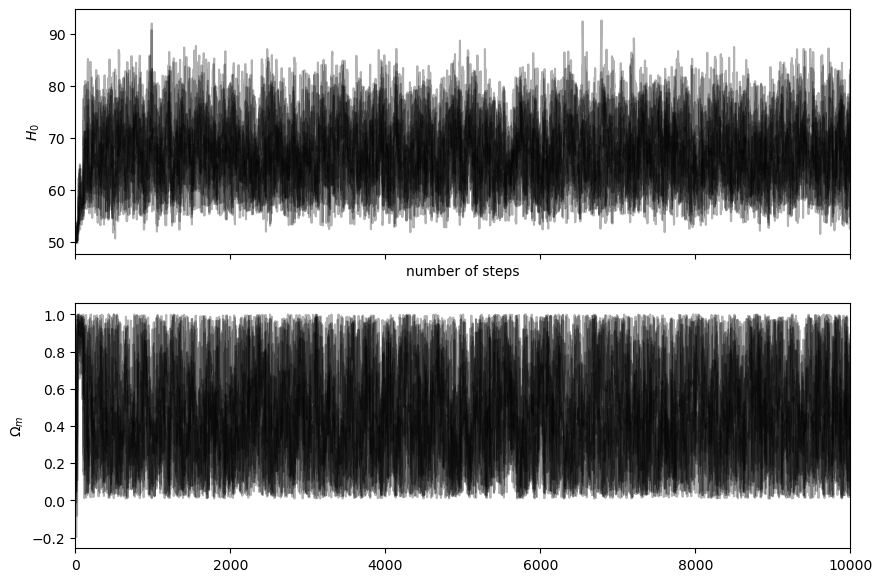

In [265]:
samples = sampler.get_chain()
    
fig, axes = plt.subplots(2, figsize=(10,7), sharex = True)

labels = [r"$H_0$", r"$\Omega_m$"]

for i in range(2):
    ax = axes[i]
    ax.plot(samples[:,:,i], "k", alpha = 0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    
axes[0].set_xlabel("number of steps")

In [266]:
tau = sampler.get_autocorr_time() #how many time do I take to have a sample that is independent from the previous one 
#burnin = int(2 * np.max(tau)) #or maybe three, in general watch the parameter you have
print(tau)

[41.4472186  38.78649546]


In [267]:
#need to discard the burn in point to thin the chain 
flat_samples = sampler.get_chain(discard=100,thin=int(max(tau)), flat=True) 
print(flat_samples.shape)

(2410, 2)


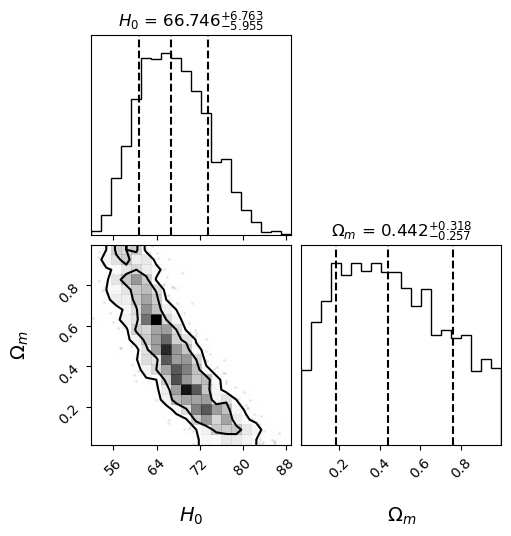

In [268]:
#what is the precision I estimate quantile
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95], #credible level
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_7076\4110408603.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

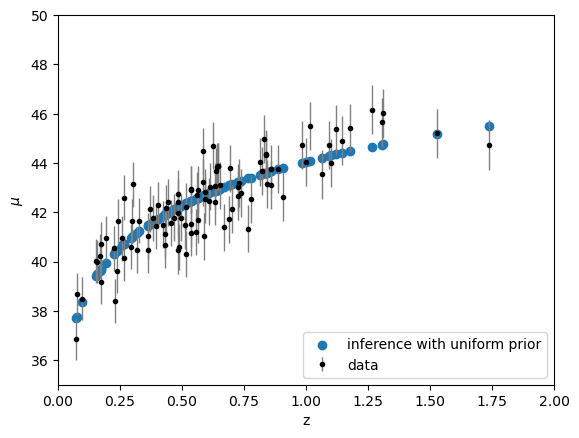

In [269]:
plt.scatter(z_sample, mu_model((66.606, 0.431), z_sample), label = "inference with uniform prior") 
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### case of a model without dark energy ($\Omega_m = 1$)

In [271]:
def mu_model_new(theta, z_data):
    H_0= float(theta)  #parameter definition 
    cosmo = FlatLambdaCDM(H0=H_0,Om0=1)

    return cosmo.distmod(z_data).value

In [272]:
#to avoid problem, better to work with log like, log prior and log posterior 
def log_like_new(theta, z_data, mu_data, sigma_mu):
    H_0 = float(theta)  #parameter definition 
    analitical_model = mu_model_new(theta,z_data)
    
    return -0.5*np.sum((mu_data-analitical_model)**2/sigma_mu**2)

In [273]:
def ln_priors_new(theta, low, up):
    H_0 = float(theta) #parameter definition
    if theta < low or theta > up:
        return -np.inf
    return 0.0

In [274]:
def log_posterior_new(theta, low, up, z_data, mu_data, sigma_mu):
    H_0 = float(theta)  #parameter definition
    prior = ln_priors_new(theta, low, up)
    if np.isfinite(prior):
        return prior + log_like_new(theta, z_data,mu_data,sigma_mu)
    else:
        return prior

In [275]:
ndim = 1  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = 10000  # number of MCMC steps to take **for each walker**

low_extreme = 50
up_extreme = 100

starting_guesses = low_extreme +1e-1*np.random.randn(nwalkers, ndim)

In [276]:
test_val = log_posterior_new(60,low_extreme, up_extreme, z_sample,mu_sample, dmu)
print(test_val)

-47.53894260415179


In [277]:
sampler_new = emcee.EnsembleSampler(nwalkers,ndim,log_posterior_new,args=(low_extreme , up_extreme, z_sample, mu_sample, dmu)) #call a function, in args i don't pass theta
sampler_new.run_mcmc(starting_guesses, nsteps)

C:\Users\User\AppData\Local\Temp\ipykernel_7076\938871033.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H_0 = float(theta)  #parameter definition
C:\Users\User\AppData\Local\Temp\ipykernel_7076\31779455.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H_0 = float(theta)  #parameter definition
C:\Users\User\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


State([[56.96544692]
 [58.09607516]
 [58.78828006]
 [61.89929331]
 [58.06533044]
 [56.9813735 ]
 [54.55915654]
 [57.80015053]
 [58.75573337]
 [58.04845775]
 [59.25442917]
 [57.40710892]
 [55.52689664]
 [60.91644139]
 [57.94351526]
 [60.80741616]
 [55.6824081 ]
 [56.50300887]
 [58.26646915]
 [59.17131327]], log_prob=[-47.13520218 -47.12102522 -47.21082771 -48.46377188 -47.11873847
 -47.13357286 -47.88097822 -47.10512646 -47.20498079 -47.11754581
 -47.31181345 -47.1053421  -47.45862159 -47.92482936 -47.11112182
 -47.87291506 -47.40646236 -47.20082527 -47.1363467  -47.2914626 ], blobs=None, random_state=('MT19937', array([1936855821,  489173960, 1765995647, 1650569424, 1721736752,
       2706298703, 4102489890, 3114972123, 1185806766, 1162154442,
       2009007852, 3754092694, 1069410472, 2346954306, 1714323665,
       3086775636, 3333989327,  300657243, 3361912949, 3476148797,
        965610788, 3468245045, 2477426944, 3145719259,  855621023,
       1912963860, 3919311866, 1521429136, 37

Text(0.5, 0, 'number of steps')

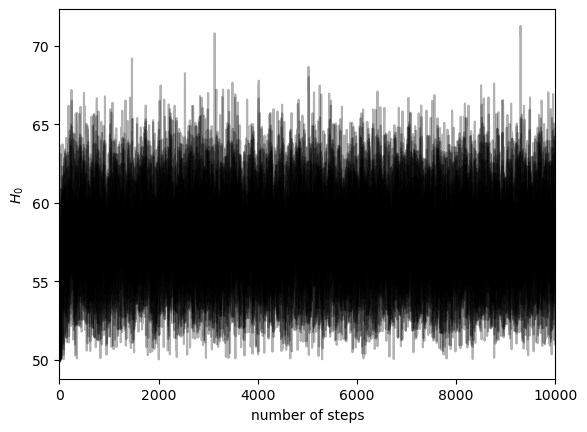

In [278]:
samples_new = sampler_new.get_chain()
plt.plot(samples_new[:,:,0], "k", alpha = 0.3)
plt.xlim(0, len(samples_new))
plt.ylabel(r"$H_0$")
plt.xlabel("number of steps")

In [279]:
tau_new = sampler_new.get_autocorr_time() #how many time do I take to have a sample that is independent from the previous one 
#burnin = int(2 * np.max(tau)) #or maybe three, in general watch the parameter you have
print(tau_new)

[29.65259208]


In [280]:
#need to discard the burn in point to thin the chain 
flat_samples_new = sampler_new.get_chain(discard=90, thin=int(max(tau)), flat=True) 
print(flat_samples_new.shape)

(4820, 1)


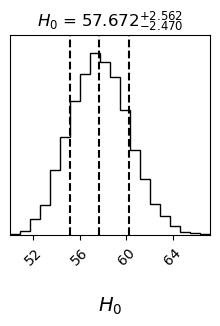

In [281]:
#what is the precision I estimate quantile
fig = corner.corner(
    flat_samples_new,
    labels=[r"$H_0$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95], #credible level
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)

(35.0, 50.0)

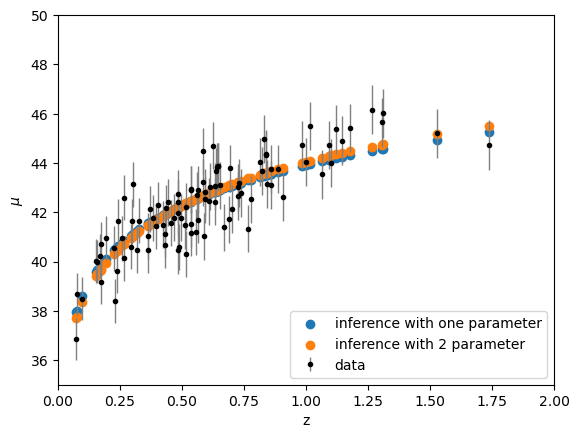

In [282]:
plt.scatter(z_sample, mu_model_new(57.739, z_sample), label = "inference with one parameter") 
plt.scatter(z_sample, mu_model((66.606, 0.431), z_sample), label = "inference with 2 parameter")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [283]:
omega_chain = flat_samples[:,1]
print(flat_samples)

[[5.95509218e+01 6.61706892e-01]
 [6.15192887e+01 7.83154298e-01]
 [7.31672338e+01 3.22200131e-01]
 ...
 [7.64776963e+01 2.98661942e-02]
 [6.20686929e+01 6.51306800e-01]
 [7.48886523e+01 1.34028815e-01]]


In [284]:
omega_m = 1.0 
kde = gaussian_kde(omega_chain)
posterior_at_omega_m = kde(omega_m).item()

In [285]:
prior_density_omegam = 1.0/(1.0-0.01)

In [286]:
bf = prior_density_omegam/posterior_at_omega_m

In [287]:
print(bf)

3.387745463243358
